#Importar librerías

In [1]:
# Libreria para importar directamente desde Kaggle
import kagglehub

# Librerías para el manejo de datos
import pandas as pd
import numpy as np

# Librerías para creación de gráficos
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

# Librerías para pruebas estadísticas
from scipy import stats as st
import math as mt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# Librería para division test y train
from sklearn.model_selection import train_test_split

# Extra: acceso a comandos del Sistema Operativo
import os

#Selección del dataset

##Importamos de kaggle

In [2]:
# Descargamos la versión más reciente del dataset desde Kaggle
path = kagglehub.dataset_download("price438/air-quality-dataset")

print("Ruta de descarga del dataset:", path)

# Construimos la ruta completa al archivo y creamos el DataFrame
# Ahora usamos el nombre de archivo correcto que encontramos al listar el directorio
df = pd.read_csv(os.path.join(path, "air_quality_dataset.csv"))

# Inspeccionamos la estructura de los datos
df.head()

Using Colab cache for faster access to the 'air-quality-dataset' dataset.
Ruta de descarga del dataset: /kaggle/input/air-quality-dataset


,Date,City,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
0,2024-10-16,Los Angeles,128.0,28.78,68.84,58.29,57.56,2.781,17.10,3.4,82.2
1,2023-01-26,Jacksonville,111.0,28.73,61.93,59.00,35.73,1.810,16.33,17.0,36.0
2,2023-10-09,Houston,91.0,20.04,47.10,66.20,43.91,2.566,15.27,1.0,68.6
3,2023-08-17,Chicago,108.0,23.39,47.90,62.85,48.89,2.332,18.49,9.4,85.7
4,2023-04-15,Austin,106.0,26.51,56.08,62.38,NaN,1.867,15.93,17.3,48.7


##Información del dataset

**Sobre el dataset**

Este dataset recopila mediciones de calidad del aire provenientes de OpenAQ, AQICN y la EPA de Estados Unidos. Incluye una amplia colección de concentraciones de contaminantes, como PM2.5, PM10, NO₂, SO₂, CO y O₃. También proporciona valores del Índice de Calidad del Aire (AQI) y condiciones meteorológicas relevantes. El dataset refleja situaciones del mundo real, ya que contiene valores faltantes, outliers (valores atípicos) y duplicados. Esto lo hace ideal para practicar el preprocesamiento de datos, la limpieza y la ingeniería de variables (features).

Gracias a la diversidad de sus variables, este dataset permite abordar tareas de machine learning como regresión, clasificación y pronóstico. También es útil para análisis exploratorio de datos (EDA) y proyectos de visualización que estudien cómo varían los niveles de contaminación a lo largo del tiempo y entre distintas regiones. Investigadores, estudiantes y entusiastas de datos pueden usarlo para construir modelos predictivos, analizar patrones de contaminación y probar flujos de trabajo de ciencia de datos aplicada al medio ambiente.

**Diccionario de datos:**

*   AQI (Air Quality Index): Índice de calidad del Aire **(posible variable target)**
*   PM2.5 (Particulate Matter 2.5): Microparticulas contaminantes que se encuentran en el aire y cuyo diámetro es menor a 2.5 micrómetros. Son respirables por lo que pueden llegar a los pulmones o torrente sanguíneo.
*   PM10 (Particulate Matter 10): Partículas sólidas o líquidas y cuyo diámetro es de 10 micrómetros o menos. Ejemplo polvo, polen o cenizas.
*   Ozone (O₃): El ozono es un gas compuesto por tres átomos de oxígeno que actúa como un escudo protector vital para la vida en la Tierra o como un contaminante nocivo para la salud humana.
*   NO2 (Nitrogen Dioxide): El dióxido de nitrógeno es un gas tóxico y contaminante atmosférico. Se produce principalmente por la quema de combustibles fósiles en el transporte y la industria, y afecta directamente la salud humana al irritar las vías respiratorias.
*   CO (Carbon Monoxide): El monóxido de carbono es un gas altamente tóxico, incoloro, inodoro e insípido. Se produce por la combustión incompleta de materiales como gas, leña, carbón o nafta, cuando no hay suficiente oxígeno.
*   SO2 (Sulfur Dioxide): El dióxido de azufre es un gas incoloro, no inflamable y altamente irritante con un olor penetrante. Es un contaminante atmosférico primario formado principalmente por la quema de combustibles fósiles (carbón y petróleo) y las emisiones volcánicas.











**Referencias numéricas de los datos:**

* AQI (Air Quality Index): Valores: De 0 a 500. Significado: 0 - 100 es aire seguro/aceptable. Mayor a 150 ya es dañino para la población general; valores cercanos a 500 representan emergencias ambientales.

* PM2.5 (Particulate Matter 2.5): Valores: De 0 a más de 250 µg/m³. Significado: Valores bajos indican aire limpio. Valores altos significan alta concentración de partículas peligrosas.

* PM10 (Particulate Matter 10): Valores: De 0 a más de 400 µg/m³. Significado: Valores altos indican ambientes polvorientos o presencia de hollín grueso.

* Ozone ($O_3$): Valores: De 0 a más de 200 ppb (partes por billón). Significado: Tiende a subir en días calurosos de verano. Valores altos causan irritación pulmonar y tos.

* NO2 (Nitrogen Dioxide): Valores: De 0 a más de 200 ppb. Significado: Valores altos disparan ataques de asma y problemas respiratorios.

* CO (Carbon Monoxide): Valores: De 0 a más de 50 ppm (partes por millón). Significado: Valores altos indican zonas de tráfico muy congestionado o encerrado.

* SO2 (Sulfur Dioxide): Valores: De 0 a más de 100 ppb. Significado: Valores altos causan fuerte irritación en ojos y garganta y es el precursor de la lluvia ácida.

#Análisis exploratorio inicial (EDA)

##Datos generales

In [3]:
# Información general del dataset (nombres de columnas y tipos de datos)
print("\nInformación general del dataset\n")
df.info()
print()
print("-"*60)

# Verificamos cuántos valores nulos hay por cada columna
print("\nCantidad de valores nulos por columna\n")
print(df.isnull().sum())
print()
print("-"*60)

# Consultamos la cantidad total de filas y columnas (forma del DataFrame)
print("\nCantidad total de filas y columnas\n")
print(df.shape)


Información general del dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5583 entries, 0 to 5582
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         5583 non-null   object 
 1   City         5583 non-null   object 
 2   AQI          5472 non-null   float64
 3   PM2.5        5486 non-null   float64
 4   PM10         5523 non-null   float64
 5   Ozone        5508 non-null   float64
 6   NO2          5490 non-null   float64
 7   CO           5421 non-null   float64
 8   SO2          5454 non-null   float64
 9   Temperature  5435 non-null   float64
 10  Humidity     5479 non-null   float64
dtypes: float64(9), object(2)
memory usage: 479.9+ KB

------------------------------------------------------------

Cantidad de valores nulos por columna

Date             0
City             0
AQI            111
PM2.5           97
PM10            60
Ozone           75
NO2             93
CO             162
SO2  

In [4]:
# Primer vistazo al dataset
print("\nPrimeras 5 filas del dataset:")
display(df.head())



Primeras 5 filas del dataset:


,Date,City,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
0,2024-10-16,Los Angeles,128.0,28.78,68.84,58.29,57.56,2.781,17.10,3.4,82.2
1,2023-01-26,Jacksonville,111.0,28.73,61.93,59.00,35.73,1.810,16.33,17.0,36.0
2,2023-10-09,Houston,91.0,20.04,47.10,66.20,43.91,2.566,15.27,1.0,68.6
3,2023-08-17,Chicago,108.0,23.39,47.90,62.85,48.89,2.332,18.49,9.4,85.7
4,2023-04-15,Austin,106.0,26.51,56.08,62.38,NaN,1.867,15.93,17.3,48.7


In [5]:
print("\nDimensiones del dataset (filas, columnas):")
print(df.shape)


Dimensiones del dataset (filas, columnas):
(5583, 11)


In [6]:
print("\nResumen estadístico de las variables numéricas:")
display(df.describe())


Resumen estadístico de las variables numéricas:


,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
count,5472.000000,5486.000000,5523.000000,5508.000000,5490.000000,5421.000000,5454.000000,5435.000000,5479.000000
mean,111.969664,26.271325,56.925913,65.779486,43.071980,2.167954,15.829078,14.848556,60.338876
std,24.152583,11.771521,15.619230,16.065461,11.077596,1.027549,8.490650,11.801714,21.586163
min,46.000000,9.210000,20.490000,28.350000,22.390000,0.722000,0.000000,-19.700000,8.600000
25%,96.000000,22.670000,48.320000,54.330000,38.150000,1.849000,12.970000,5.000000,42.600000
50%,110.000000,25.630000,55.890000,62.990000,42.640000,2.134000,15.550000,14.600000,60.800000
75%,126.000000,29.070000,64.590000,75.252500,47.270000,2.424000,18.197500,24.800000,78.700000
max,497.000000,461.330000,448.640000,283.970000,400.990000,47.281000,290.760000,53.500000,100.000000


In [7]:
print("\nNombres de las columnas:")
display(df.columns)


Nombres de las columnas:


Index(['Date', 'City', 'AQI', 'PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2',
       'Temperature', 'Humidity'],
      dtype='object')

In [8]:
print("\nColumnas numéricas:")
display(df.select_dtypes(include="number").columns)

print("\nColumnas no numéricas:")
display(df.select_dtypes(exclude="number").columns)


Columnas numéricas:


Index(['AQI', 'PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2', 'Temperature',
       'Humidity'],
      dtype='object')


Columnas no numéricas:


Index(['Date', 'City'], dtype='object')

In [9]:
print(df['City'].unique())

['Los Angeles' 'Jacksonville' 'Houston' 'Chicago' 'Austin' 'San Antonio'
 'New York' 'Dallas' 'San Diego' 'Phoenix' 'Fort Worth' 'Philadelphia'
 'San Jose' 'Charlotte' 'Columbus']


In [10]:
# Definimos tus columnas numéricas
cols_numericas = [
    'AQI', 'PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2', 'Temperature',
       'Humidity'
]

# Obtenemos min y max
min_max_df = df[cols_numericas].agg(['min', 'max']).T
print("Límites de las variables numéricas:")
print(min_max_df)

Límites de las variables numéricas:
                min      max
AQI          46.000  497.000
PM2.5         9.210  461.330
PM10         20.490  448.640
Ozone        28.350  283.970
NO2          22.390  400.990
CO            0.722   47.281
SO2           0.000  290.760
Temperature -19.700   53.500
Humidity      8.600  100.000


In [11]:
print("\nLos 10 valores más frecuentes de la columna 'City':")
display(df["City"].value_counts().head(10))


Los 10 valores más frecuentes de la columna 'City':


,count
City,
San Diego,391
Jacksonville,389
Los Angeles,389
San Antonio,386
Austin,383
San Jose,381
Fort Worth,375
Columbus,374
Houston,365


##Visualizaciones

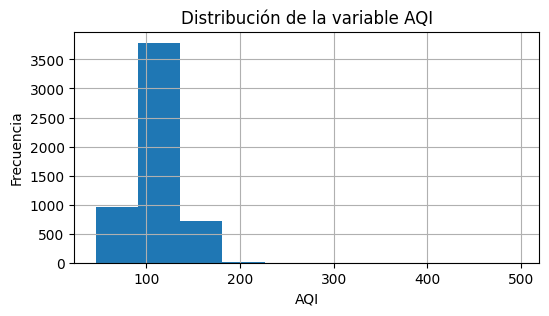

In [12]:
# HISTOGRAMA: Distribución de AQI
plt.figure(figsize=(6, 3))
df["AQI"].hist(bins=10)
plt.title("Distribución de la variable AQI")
plt.xlabel("AQI")
plt.ylabel("Frecuencia")
plt.show()

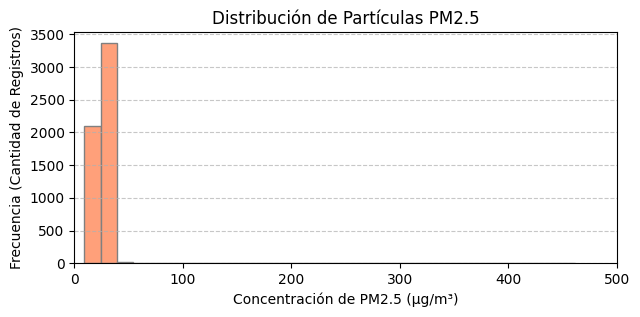

In [13]:
# HISTOGRAMA: Distribución de PM2.5
plt.figure(figsize=(7, 3))

# Usamos PM2.5 sin NULOS
plt.hist(df['PM2.5'].dropna(), bins=30, color='lightsalmon', edgecolor='grey')

plt.title('Distribución de Partículas PM2.5')
plt.xlabel('Concentración de PM2.5 (µg/m³)')
plt.ylabel('Frecuencia (Cantidad de Registros)')

# Máximo 461
plt.xlim(0, 500)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

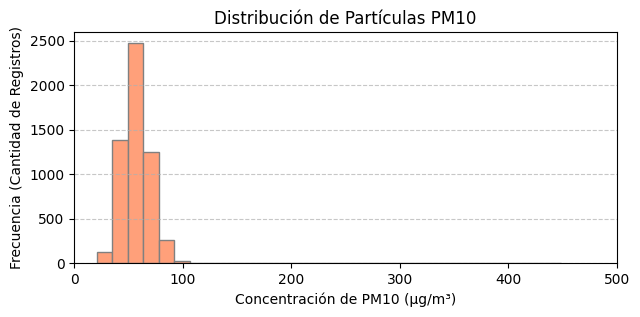

In [14]:
# HISTOGRAMA: Distribución de PM10
plt.figure(figsize=(7, 3))

# Usamos PM10 sin NULOS
plt.hist(df['PM10'].dropna(), bins=30, color='lightsalmon', edgecolor='grey')

plt.title('Distribución de Partículas PM10')
plt.xlabel('Concentración de PM10 (µg/m³)')
plt.ylabel('Frecuencia (Cantidad de Registros)')

# Máximo 448
plt.xlim(0, 500)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

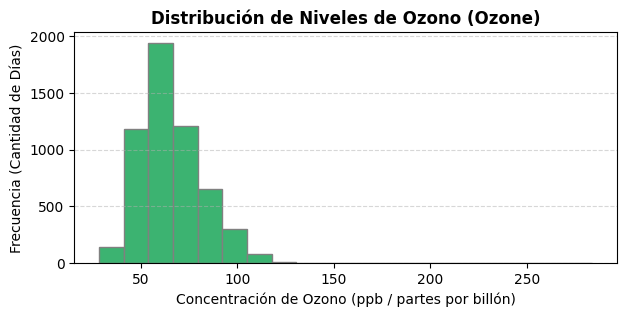

In [15]:
# HISTOGRAMA: Distribución de los niveles de Ozono
plt.figure(figsize=(7, 3))

# Usamos 'Ozone' sin nulos
plt.hist(df['Ozone'].dropna(), bins=20, color='mediumseagreen', edgecolor='grey')

plt.title('Distribución de Niveles de Ozono (Ozone)', fontsize=12, fontweight='bold')
plt.xlabel('Concentración de Ozono (ppb / partes por billón)')
plt.ylabel('Frecuencia (Cantidad de Días)')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

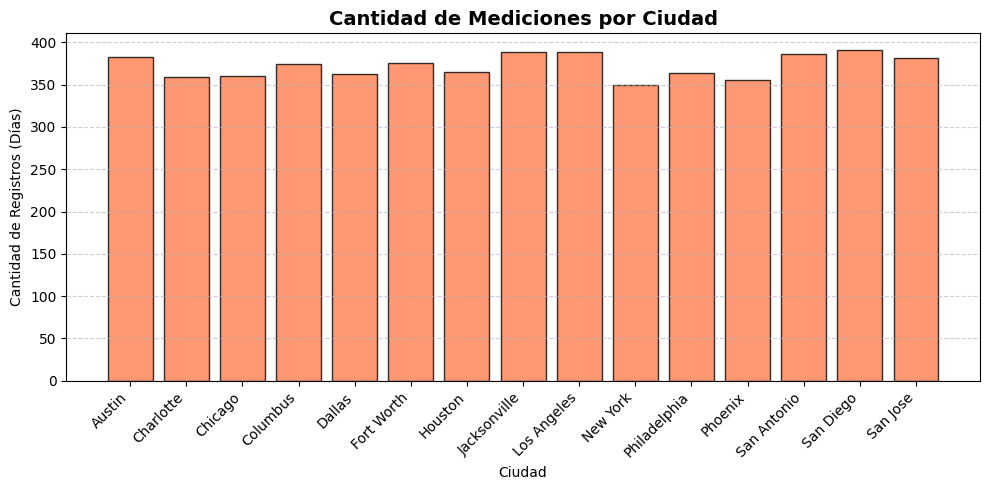

In [16]:
# GRÁFICO DE BARRAS: Distribución de Mediciones por Ciudad

# Contamos los registros por ciudad y los ordenamos alfabéticamente
cat_counts = df['City'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(cat_counts.index, cat_counts.values, color='coral', edgecolor='black', alpha=0.8)

plt.title('Cantidad de Mediciones por Ciudad', fontsize=14, fontweight='bold')
plt.xlabel('Ciudad')
plt.ylabel('Cantidad de Registros (Días)')

# Rotamos las etiquetas 45 grados obligatoriamente para que los nombres no se pisen
# ha='right' alinea el texto al borde de la barra de forma prolija
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.6)

# tight_layout evita que los nombres de las ciudades se corten abajo de la imagen
plt.tight_layout()
plt.show()

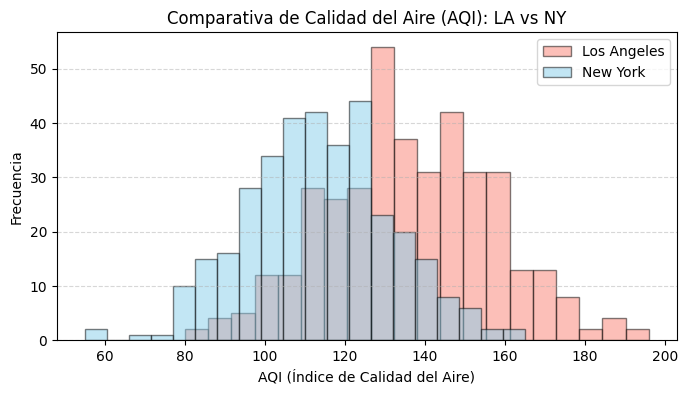

In [17]:
# HISTOGRAMA COMPARATIVO: AQI entre Los Angeles y New York
plt.figure(figsize=(8, 4))

aqi_la = df[df['City'] == 'Los Angeles']['AQI'].dropna()
aqi_ny = df[df['City'] == 'New York']['AQI'].dropna()

#histogramas superpuestos
plt.hist(aqi_la, bins=20, alpha=0.5, label='Los Angeles', color='salmon', edgecolor='black')
plt.hist(aqi_ny, bins=20, alpha=0.5, label='New York', color='skyblue', edgecolor='black')

plt.title('Comparativa de Calidad del Aire (AQI): LA vs NY')
plt.xlabel('AQI (Índice de Calidad del Aire)')
plt.ylabel('Frecuencia')
plt.legend(loc='upper right')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

/tmp/ipykernel_14946/2855885870.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


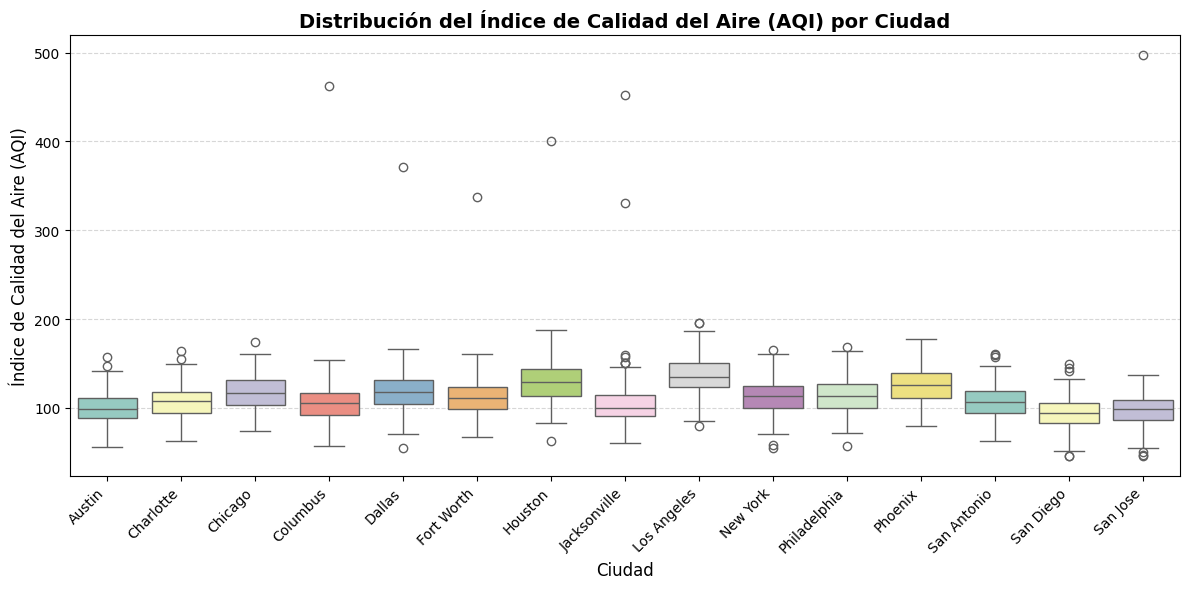

In [18]:
# BOXPLOT: Distribución del AQI por Ciudad
plt.figure(figsize=(12, 6))

# Eliminamos nulos de AQI
df_filtrado = df.dropna(subset=['AQI'])

# Creamos el boxplot ordenando las ciudades alfabéticamente para mayor prolijidad
sns.boxplot(
    x='City',
    y='AQI',
    data=df_filtrado,
    order=sorted(df_filtrado['City'].unique()),
    palette='Set3'
)

plt.title('Distribución del Índice de Calidad del Aire (AQI) por Ciudad', fontsize=14, fontweight='bold')
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Índice de Calidad del Aire (AQI)', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##Correlación entre variables

In [19]:
# MATRIZ DE CORRELACIÓN
# La matriz solo considera campos numéricos (no toma en cuenta City ni Date porque son objects)
matriz_correlacion = df.corr(numeric_only=True)
matriz_correlacion

,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
AQI,1.000000,0.321194,0.581504,0.473272,0.201573,0.116200,0.091323,0.416951,-0.375323
PM2.5,0.321194,1.000000,0.286300,0.188388,0.100460,0.066762,0.038198,0.168407,-0.150548
PM10,0.581504,0.286300,1.000000,0.389354,0.184909,0.116340,0.080795,0.353826,-0.331900
Ozone,0.473272,0.188388,0.389354,1.000000,0.114184,0.065607,0.046794,0.707934,-0.622580
NO2,0.201573,0.100460,0.184909,0.114184,1.000000,0.121997,0.086735,0.013293,-0.009868
CO,0.116200,0.066762,0.116340,0.065607,0.121997,1.000000,0.061815,0.000247,-0.000170
SO2,0.091323,0.038198,0.080795,0.046794,0.086735,0.061815,1.000000,-0.005670,0.010688
Temperature,0.416951,0.168407,0.353826,0.707934,0.013293,0.000247,-0.005670,1.000000,-0.839779
Humidity,-0.375323,-0.150548,-0.331900,-0.622580,-0.009868,-0.000170,0.010688,-0.839779,1.000000


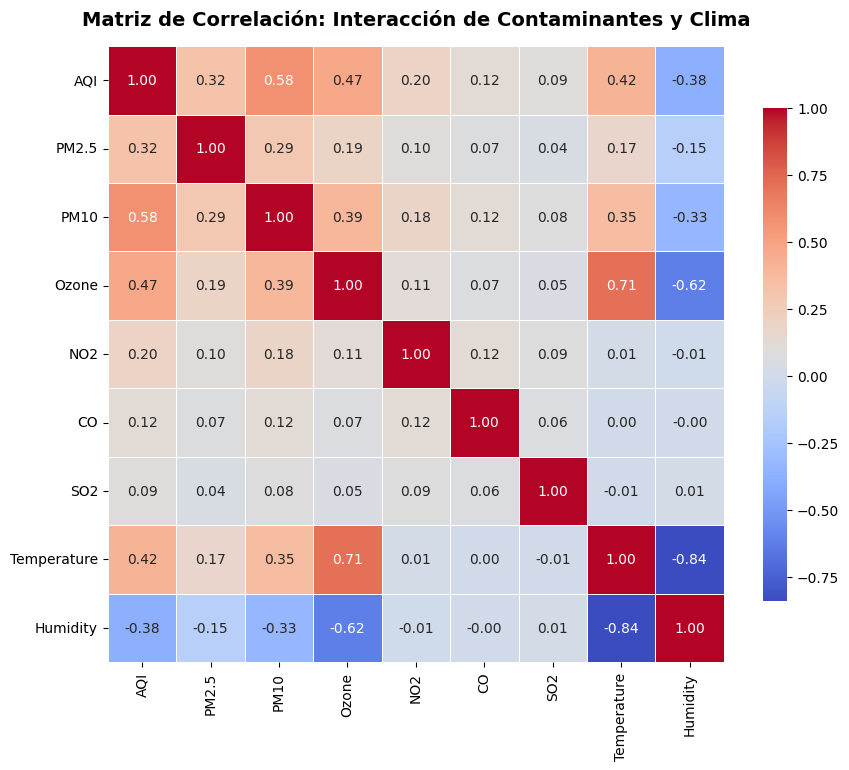

In [20]:
# HEATMAP: Visualización de la Matriz de Correlación
plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title('Matriz de Correlación: Interacción de Contaminantes y Clima', fontsize=14, fontweight='bold', pad=15)
plt.show()


##Análisis específicos

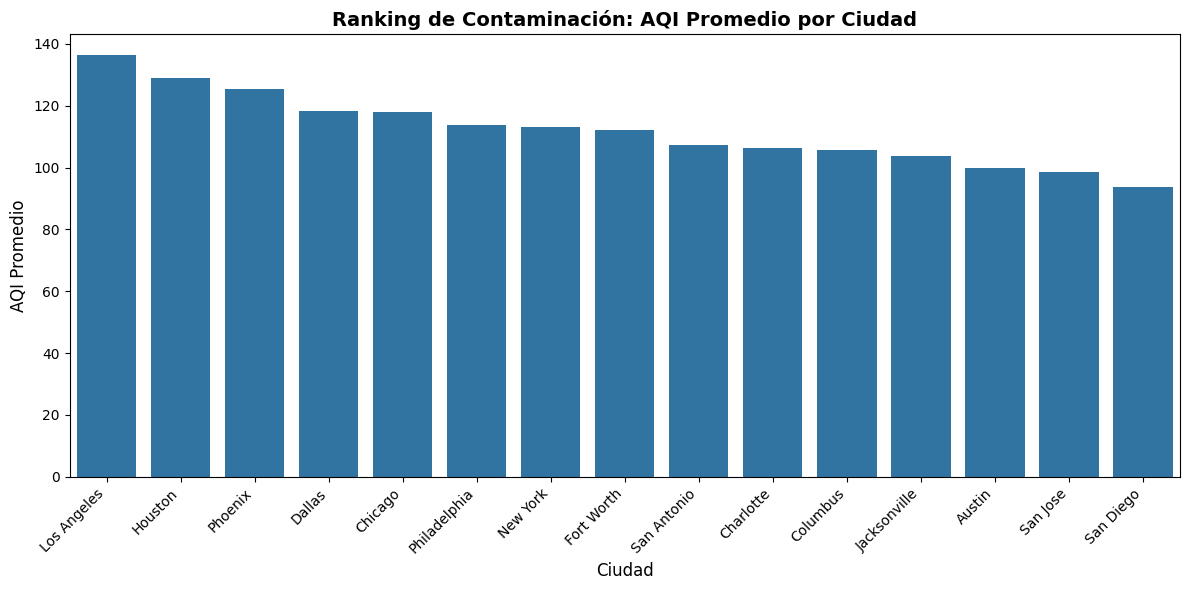

In [21]:
# GRÁFICO DE BARRAS: AQI Promedio por Ciudad

# Calculamos el orden de las ciudades según su AQI promedio (de mayor a menor)
orden_contaminacion = df.groupby('City')['AQI'].mean().sort_values(ascending=False).index
plt.figure(figsize=(12, 6))

sns.barplot(
    x='City',
    y='AQI',
    data=df,
    order=orden_contaminacion,
    #palette='viridis',
    errorbar=None
)

plt.xticks(rotation=45, ha='right')

plt.title('Ranking de Contaminación: AQI Promedio por Ciudad', fontsize=14, fontweight='bold')
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('AQI Promedio', fontsize=12)

plt.tight_layout()
plt.show()

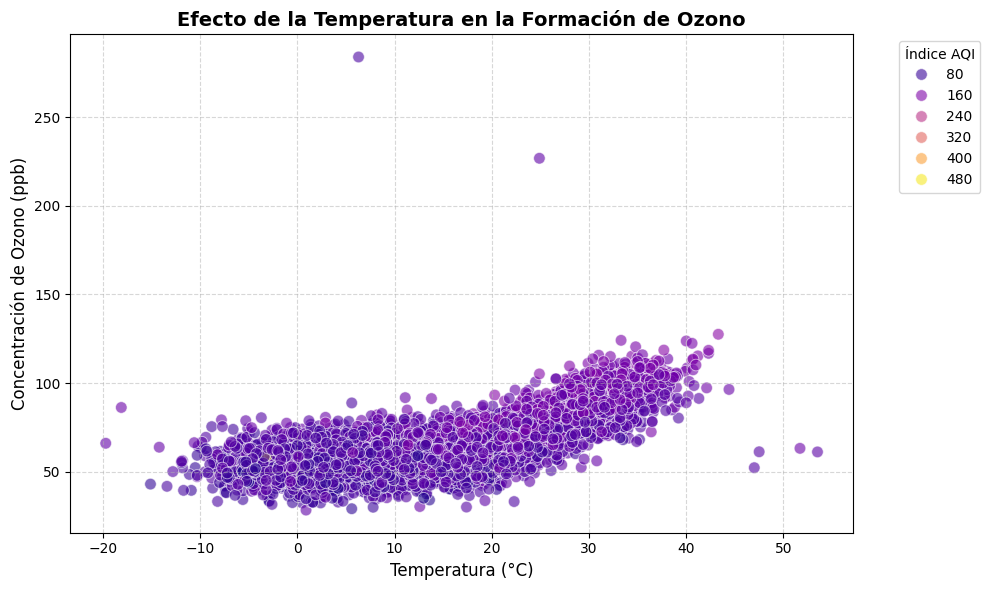

In [22]:
# SCATTER PLOT: Relación entre Temperatura y Ozono

plt.figure(figsize=(10, 6))

# sin nulos
df_scatter = df.dropna(subset=['Temperature', 'Ozone', 'AQI'])

# x: Factor climático (Temperatura)
# y: Contaminante secundario (Ozono)
# hue: El color representará el AQI general (a mayor índice, peor calidad)
sns.scatterplot(
    data=df_scatter,
    x="Temperature",
    y="Ozone",
    hue="AQI",
    palette="plasma",
    s=70,
    alpha=0.6
)

plt.title("Efecto de la Temperatura en la Formación de Ozono", fontsize=14, fontweight='bold')
plt.xlabel("Temperatura (°C)", fontsize=12)
plt.ylabel("Concentración de Ozono (ppb)", fontsize=12)

plt.legend(title="Índice AQI", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

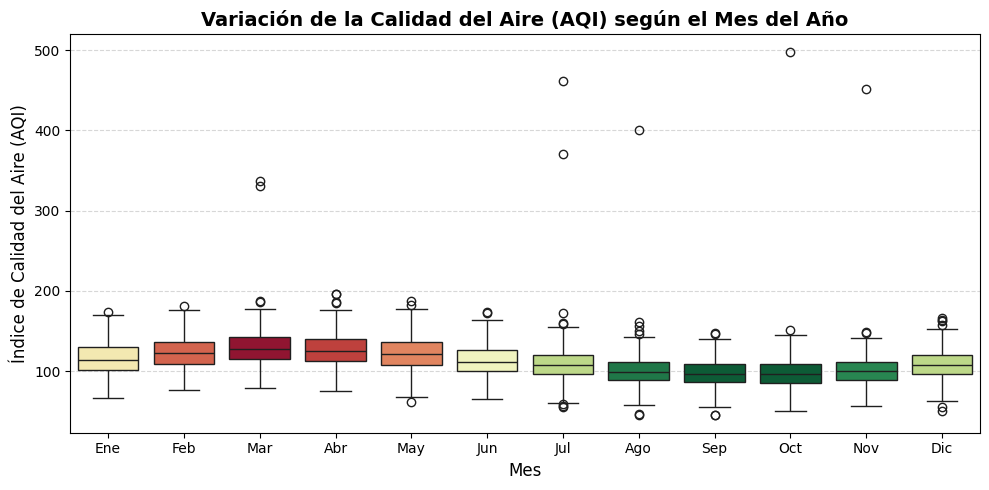

In [23]:
# BOXPLOT: Estacionalidad del AQI con Colores de Semáforo


# Creamos la copia temporal y preparamos las fechas
df_temporal = df.dropna(subset=['AQI']).copy()
df_temporal['Date'] = pd.to_datetime(df_temporal['Date'])
df_temporal['Month'] = df_temporal['Date'].dt.month

meses_nombres = {1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
                 7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'}
df_temporal['Month_Name'] = df_temporal['Month'].map(meses_nombres)
orden_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# --- LÓGICA DE SEMÁFORO ---
# Calculamos la mediana de AQI por mes para determinar la gravedad real
medianas_mensuales = df_temporal.groupby('Month_Name')['AQI'].median().reindex(orden_meses)

# Creamos un normalizador para mapear los valores de AQI al rango [0, 1]
norm = mcolors.Normalize(vmin=medianas_mensuales.min(), vmax=medianas_mensuales.max())

# Usamos 'RdYlGn_r' (Red-Yellow-Green Reversado) -> Bajo AQI será Verde, Alto AQI será Rojo
cmap = plt.cm.RdYlGn_r

# Generamos un diccionario que le asigna a cada mes su color exacto según su contaminación
paleta_semaforo = {mes: cmap(norm(valor)) for mes, valor in medianas_mensuales.items()}
# -----------------------------------

plt.figure(figsize=(10, 5))

sns.boxplot(
    x='Month_Name',
    y='AQI',
    data=df_temporal,
    order=orden_meses,
    palette=paleta_semaforo,
    hue='Month_Name',
    legend=False
)

plt.title('Variación de la Calidad del Aire (AQI) según el Mes del Año', fontsize=14, fontweight='bold')
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Índice de Calidad del Aire (AQI)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##Valores atípicos

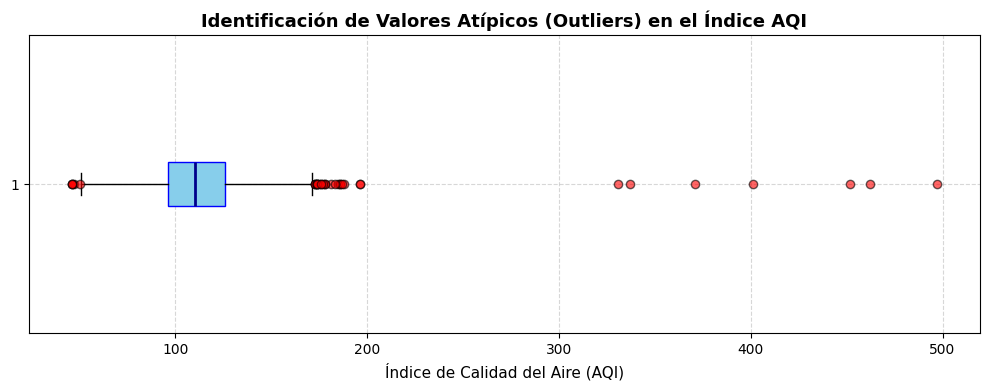

In [24]:
# DETECCIÓN DE OUTLIERS: Distribución Horizontal del AQI

plt.figure(figsize=(10, 4))

# sin nulos
plt.boxplot(
    df["AQI"].dropna(),
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="skyblue", color="blue"),
    medianprops=dict(color="darkblue", linewidth=2),
    flierprops=dict(markerfacecolor='red', marker='o', markersize=6, alpha=0.6)
)

plt.title("Identificación de Valores Atípicos (Outliers) en el Índice AQI", fontsize=13, fontweight='bold')
plt.xlabel("Índice de Calidad del Aire (AQI)", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##Valores nulos

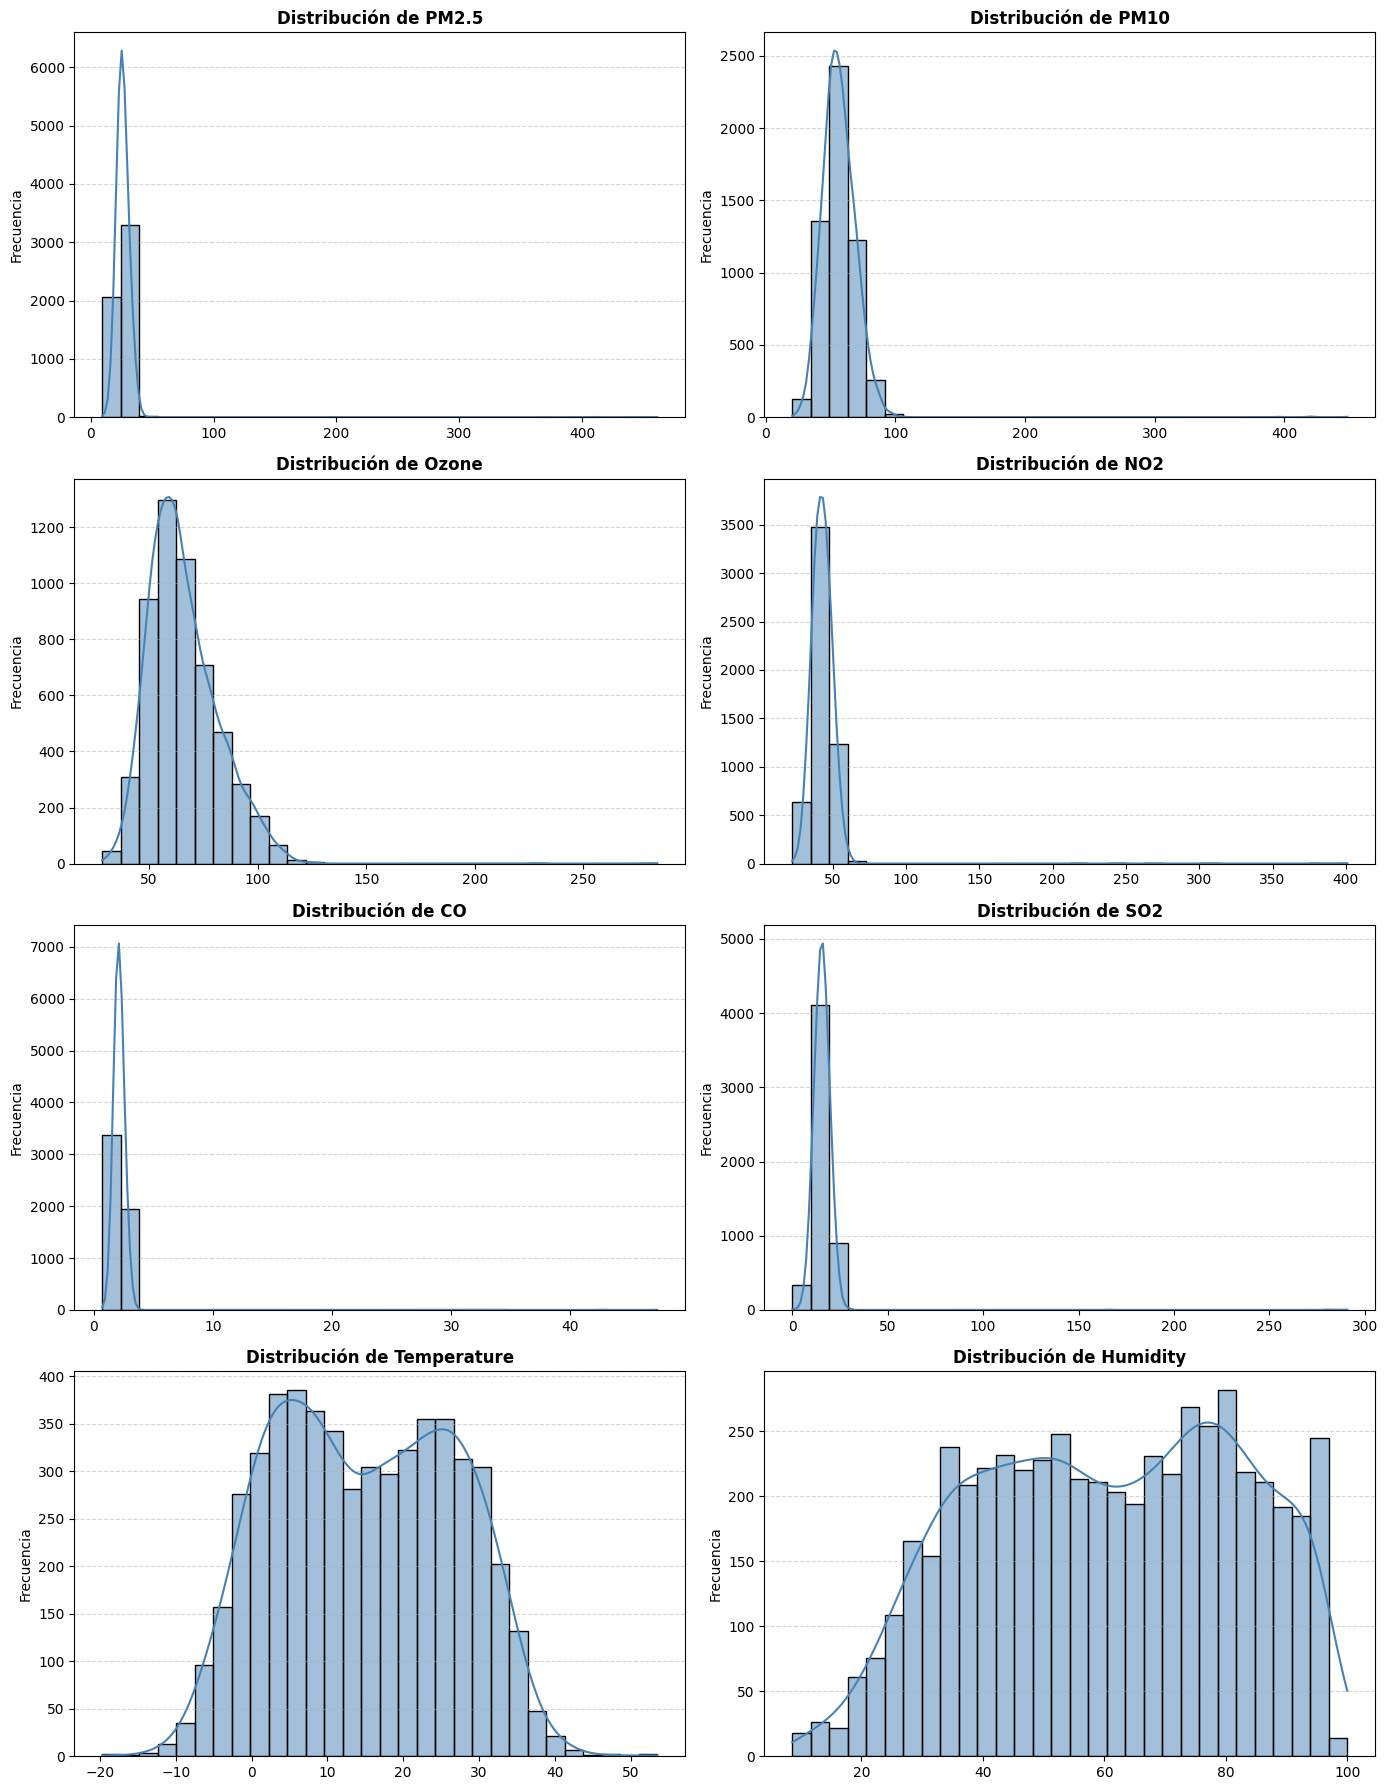

In [36]:
# VISUALIZACIÓN DE DISTRIBUCIONES ANTES DE IMPUTAR NULOS

# Definimos la lista de las 8 variables ambientales
cols_ambientales = ['PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2', 'Temperature', 'Humidity']

# Creamos una figura grande con una grilla de 4 filas y 2 columnas
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))

# Aplanamos la matriz de gráficos para poder recorrerla con un solo índice
axes = axes.flatten()

# Iteramos por cada variable numérica
for i, col in enumerate(cols_ambientales):
    # Dibujamos el histograma con la curva de densidad (KDE)
    sns.histplot(
        data=df_proc,
        x=col,
        kde=True,
        color='steelblue',
        ax=axes[i],
        bins=30
    )

    # Personalizamos cada subgráfico
    axes[i].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')  # Quitamos el label automático para que quede más limpio
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Ajustamos el espaciado para que ningún título se pise con los gráficos de arriba
plt.tight_layout()
plt.show()

In [25]:
# AUDITORÍA DE NULOS

nulos_cantidad = df.isnull().sum()

nulos_porcentaje = (df.isnull().sum() / len(df)) * 100

tabla_nulos = pd.DataFrame({
    'Cantidad Nulos': nulos_cantidad,
    'Porcentaje (%)': nulos_porcentaje
}).sort_values(by='Cantidad Nulos', ascending=False)

print("Resumen de valores faltantes por columna:")
tabla_nulos

Resumen de valores faltantes por columna:


,Cantidad Nulos,Porcentaje (%)
CO,162,2.901666
Temperature,148,2.650905
SO2,129,2.310586
AQI,111,1.988178
Humidity,104,1.862798
PM2.5,97,1.737417
NO2,93,1.665771
Ozone,75,1.343364
PM10,60,1.074691
City,0,0.000000


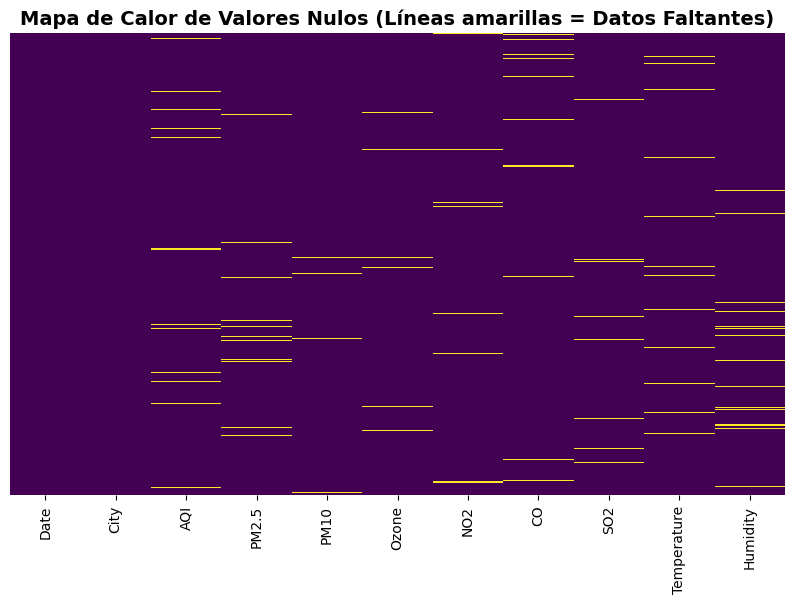

In [26]:
# MAPA DE CALOR DE NULOS
plt.figure(figsize=(10, 6))

# df.isnull() devuelve True (1) donde hay nulo y False (0) donde hay dato
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title("Mapa de Calor de Valores Nulos (Líneas amarillas = Datos Faltantes)", fontsize=14, fontweight='bold')
plt.show()

In [27]:
# Filtramos el dataset para ver solo las filas donde AQI es nulo
filas_con_aqi_nulo = df[df['AQI'].isnull()]

print(f"Visualizando las primeras 5 filas con AQI faltante (Total: {len(filas_con_aqi_nulo)}):")
filas_con_aqi_nulo.head()

Visualizando las primeras 5 filas con AQI faltante (Total: 111):


,Date,City,AQI,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
53,2024-07-24,Houston,NaN,28.70,62.28,60.15,50.29,2.828,17.72,9.0,67.5
64,2024-10-20,San Diego,NaN,18.24,43.12,50.41,40.91,1.610,11.69,1.4,88.6
81,2024-06-25,Phoenix,NaN,30.14,65.22,58.07,46.12,2.491,NaN,12.5,80.9
194,2023-03-25,San Antonio,NaN,28.83,70.79,89.26,43.98,1.735,10.38,29.2,42.1
232,2024-05-15,Phoenix,NaN,27.02,61.87,51.55,39.12,NaN,15.13,21.7,26.1


In [28]:
# Contamos cuántas filas tienen un valor exactamente igual a 0 en la columna AQI
cantidad_ceros = (df['AQI'] == 0).sum()

print(f"Cantidad de registros con AQI igual a 0: {cantidad_ceros}")

if cantidad_ceros > 0:
    print("\nMuestra de filas con AQI en cero:")
    display(df[df['AQI'] == 0].head())

Cantidad de registros con AQI igual a 0: 0


De todas formas, en la variable AQI el valor mínimo era 46, es decir, no hay ceros.

#Limpieza de datos

Dado que la variable target es el índice AQI, no tomaremos en cuenta los registros que tienen este dato vacio o nulo.

In [29]:
# Creamos df_proc eliminando únicamente las filas donde AQI es NaN
df_proc = df.dropna(subset=['AQI']).copy()

# Verificamos el impacto del filtro en las dimensiones
print(f"Filas en el dataset original: {len(df)}")
print(f"Filas en el nuevo dataset procesado (df_proc): {len(df_proc)}")
print(f"Registros eliminados por nulos en la variable objetivo: {len(df) - len(df_proc)}")

Filas en el dataset original: 5583
Filas en el nuevo dataset procesado (df_proc): 5472
Registros eliminados por nulos en la variable objetivo: 111


#Transformaciones básicas

##Cambiar fecha

In [30]:
# TRANSFORMACIÓN DE FECHAS: AÑO Y MES NUMÉRICOS

# 1. Convertimos la columna original de texto a formato fecha real
df_proc["Date"] = pd.to_datetime(df_proc["Date"])

# 2. Extraemos el año y el mes como columnas numéricas discretas
df_proc["Anio"] = df_proc["Date"].dt.year
df_proc["Mes"] = df_proc["Date"].dt.month

# Verificamos los tipos de datos de las nuevas columnas para estar seguros
print("Tipos de datos asignados:")
print(df_proc[["Date", "Anio", "Mes"]].dtypes)

# Mostramos un vistazo del resultado
df_proc[["Date", "Anio", "Mes"]].head()

Tipos de datos asignados:
Date    datetime64[ns]
Anio             int32
Mes              int32
dtype: object


,Date,Anio,Mes
0,2024-10-16,2024,10
1,2023-01-26,2023,1
2,2023-10-09,2023,10
3,2023-08-17,2023,8
4,2023-04-15,2023,4


##Crear Dummys

In [31]:
# ONE-HOT ENCODING: Creación de Dummies para las Ciudades

# Aplicamos get_dummies directamente al dataframe de trabajo
df_proc = pd.get_dummies(df_proc, columns=['City'], prefix='City', dtype=int)

# Buscamos todas las columnas que empiecen con "City_"
columnas_city = [col for col in df_proc.columns if col.startswith('City_')]
display(df_proc[columnas_city].head())

,City_Austin,City_Charlotte,City_Chicago,City_Columbus,City_Dallas,City_Fort Worth,City_Houston,City_Jacksonville,City_Los Angeles,City_New York,City_Philadelphia,City_Phoenix,City_San Antonio,City_San Diego,City_San Jose
0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


##Escalar variables

In [32]:
# Tomamos la columna AQI de nuestro dataset ya procesado (df_proc)

experimento_escalado = df_proc[["AQI"]].copy()

print("Cantidad de registros para el experimento:", len(experimento_escalado))
experimento_escalado.head()

Cantidad de registros para el experimento: 5472


,AQI
0,128.0
1,111.0
2,91.0
3,108.0
4,106.0


In [33]:
# APLICAMOS NORMALIZACIÓN A AQI (MIN-MAX)

# Creamos el escalador Min-Max
escalador_minmax = MinMaxScaler()

# Generamos la nueva columna normalizada
experimento_escalado["AQI_Normalizado"] = escalador_minmax.fit_transform(experimento_escalado[["AQI"]])

experimento_escalado.head(10)

,AQI,AQI_Normalizado
0,128.0,0.181818
1,111.0,0.144124
2,91.0,0.099778
3,108.0,0.137472
4,106.0,0.133038
5,132.0,0.190687
6,94.0,0.106430
7,142.0,0.212860
8,176.0,0.288248
9,80.0,0.075388


In [34]:
# APLICAMOS ESTANDARIZACIÓN A AQI (STANDARD SCALER)

# Creamos el escalador Standard
escalador_standard = StandardScaler()

# Generamos la nueva columna estandarizada
experimento_escalado["AQI_Estandarizado"] = escalador_standard.fit_transform(experimento_escalado[["AQI"]])

experimento_escalado.head(10)

,AQI,AQI_Normalizado,AQI_Estandarizado
0,128.0,0.181818,0.663772
1,111.0,0.144124,-0.040151
2,91.0,0.099778,-0.868296
3,108.0,0.137472,-0.164373
4,106.0,0.133038,-0.247187
5,132.0,0.190687,0.829401
6,94.0,0.106430,-0.744074
7,142.0,0.212860,1.243473
8,176.0,0.288248,2.651318
9,80.0,0.075388,-1.323775


In [35]:
# COMPARAMOS LA VARIABLE ORIGINAL Y SUS VERSIONES ESCALADAS

# Mostramos el AQI original, el rango 0-1, y el centrado en 0
display(experimento_escalado[["AQI", "AQI_Normalizado", "AQI_Estandarizado"]].head(10))

# Resumen estadístico para defender la elección en la entrega
print("\nResumen estadístico del experimento:")
display(experimento_escalado.describe().T[["min", "mean", "std", "max"]])

,AQI,AQI_Normalizado,AQI_Estandarizado
0,128.0,0.181818,0.663772
1,111.0,0.144124,-0.040151
2,91.0,0.099778,-0.868296
3,108.0,0.137472,-0.164373
4,106.0,0.133038,-0.247187
5,132.0,0.190687,0.829401
6,94.0,0.106430,-0.744074
7,142.0,0.212860,1.243473
8,176.0,0.288248,2.651318
9,80.0,0.075388,-1.323775



Resumen estadístico del experimento:


,min,mean,std,max
AQI,46.000000,1.119697e+02,24.152583,497.000000
AQI_Normalizado,0.000000,1.462742e-01,0.053553,1.000000
AQI_Estandarizado,-2.731621,-4.414922e-17,1.000091,15.943037


In [37]:
# ESTANDARIZACIÓN DEFINITIVA DE LAS VARIABLES PREDICTORAS

cols_ambientales = [
    'PM2.5', 'PM10', 'Ozone', 'NO2', 'CO', 'SO2', 'Temperature', 'Humidity'
]

final_scaler = StandardScaler()

# Aplicamos la transformación
df_proc[cols_ambientales] = final_scaler.fit_transform(df_proc[cols_ambientales])

# Verificamos
print("Cantidad de nulos por columna DESPUÉS del escalado:")
print(df_proc[cols_ambientales].isnull().sum())

print("\nVerificación de estadísticas (Media ~ 0, Desvío = 1):")
display(df_proc[cols_ambientales].agg(['mean', 'std']).T.round(2))

df_proc[cols_ambientales].head()

Cantidad de nulos por columna DESPUÉS del escalado:
PM2.5           97
PM10            60
Ozone           72
NO2             91
CO             159
SO2            125
Temperature    144
Humidity       103
dtype: int64

Verificación de estadísticas (Media ~ 0, Desvío = 1):


,mean,std
PM2.5,0.0,1.0
PM10,-0.0,1.0
Ozone,-0.0,1.0
NO2,0.0,1.0
CO,0.0,1.0
SO2,0.0,1.0
Temperature,-0.0,1.0
Humidity,0.0,1.0


,PM2.5,PM10,Ozone,NO2,CO,SO2,Temperature,Humidity
0,0.211607,0.761854,-0.463427,1.298450,0.590841,0.147954,-0.968599,1.012209
1,0.207394,0.320735,-0.419197,-0.658723,-0.346019,0.057948,0.185708,-1.129574
2,-0.524735,-0.625978,0.029326,0.074657,0.383400,-0.065956,-1.172300,0.381728
3,-0.242499,-0.574908,-0.179362,0.521140,0.157628,0.310432,-0.459346,1.174466
4,0.020360,-0.052715,-0.208640,NaN,-0.291023,0.011192,0.211171,-0.540815


#Selección de variables relevantes

Se seleccionan las variables predictoras asegurando que todas tengan un formato apto para el modelo (numéricas continuas, discretas o variables dummy), excluyendo identificadores y formatos no soportados como fechas nativas.

#División del dataset en conjuntos de entrenamiento y prueba

In [43]:
# Eliminamos el AQI original, el nuevo código de riesgo y la fecha nativa
X = df_proc.drop(columns=['AQI', 'Date'])
y = df_proc['AQI']


# DIVIDIMOS LOS DATOS EN ENTRENAMIENTO (80%) Y PRUEBA (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# VERIFICACIÓN DE DIMENSIONES Y BALANCE

print(f"Set de Entrenamiento: {X_train.shape[0]} registros")
print(f"Set de Prueba: {X_test.shape[0]} registros")

print("Resumen estadístico del Target en Entrenamiento (y_train):")
print(y_train.describe().round(2))

Set de Entrenamiento: 4377 registros
Set de Prueba: 1095 registros
Resumen estadístico del Target en Entrenamiento (y_train):
count    4377.00
mean      111.79
std        24.69
min        46.00
25%        96.00
50%       110.00
75%       126.00
max       497.00
Name: AQI, dtype: float64
